In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Raw data path
DATA_PATH = "data/raw"

HELD_ASSETS = ['SPY', 'QQQ', 'JPM', 'XLI', 'JNJ', 'KO', 'NEE', 'IEF', 'GLD', 'XLE', 'UPS']

file_map = {
    'SPY': 'spy_us_d.csv',
    'QQQ': 'qqq_us_d.csv',
    'JPM': 'jpm_us_d.csv',
    'XLI': 'xli_us_d.csv',
    'JNJ': 'jnj_us_d.csv',
    'KO':  'ko_us_d.csv',
    'NEE': 'nee_us_d.csv',
    'IEF': 'ief_us_d.csv',
    'GLD': 'gld_us_d.csv',
    'XLE': 'xle_us_d.csv',
    'UPS': 'ups_us_d.csv',
}

In [ ]:
# Load and clean each price series first
frames = {}

for ticker, fname in file_map.items():
    df = pd.read_csv(
        os.path.join(DATA_PATH, fname),
        parse_dates=['Date']
    )

    # Keep only needed columns
    df = df[['Date', 'Close']].copy()

    # Ensure numeric close
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

    # Sort and remove duplicate dates
    df = df.sort_values('Date')
    df = df.drop_duplicates(subset='Date', keep='last')

    # Remove invalid prices
    df = df[df['Close'] > 0]

    # Store as named series
    series = df.set_index('Date')['Close']
    series.name = ticker
    frames[ticker] = series

prices_raw = pd.DataFrame(frames)
prices_raw.index.name = 'Date'

print("Raw merged shape:", prices_raw.shape)
print("Raw date range:", prices_raw.index.min().date(), "->", prices_raw.index.max().date())
prices_raw.head(100)

Raw merged shape: (5356, 11)
Raw date range: 2005-01-03 -> 2026-04-17


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-01-03,NaN,33.8267,28.2246,NaN,44.5777,14.3330,NaN,NaN,NaN,NaN,59.9527
2005-01-04,NaN,33.2080,27.6930,NaN,44.4364,14.1324,NaN,NaN,NaN,NaN,59.1922
2005-01-05,NaN,33.0054,27.7481,NaN,44.4080,14.0708,NaN,NaN,NaN,NaN,59.0732
2005-01-06,NaN,32.8342,27.8974,NaN,44.5393,14.1843,NaN,NaN,NaN,NaN,59.0089
2005-01-07,NaN,33.0151,27.6842,NaN,44.3756,14.2019,NaN,NaN,NaN,NaN,58.8959


In [4]:
# Diagnostic view before final cleaning
subset = prices_raw.loc['2005-02-25':'2026-04-17'].copy()

print("Subset shape before dropna:", subset.shape)
print("Subset date range:", subset.index.min().date(), "->", subset.index.max().date())

print("\nMissing values per asset:")
print(subset.isna().sum().sort_values())

complete_rows = subset.dropna(how='any')
print("\nComplete rows:", len(complete_rows))
print("Complete-date ratio:", round(len(complete_rows) / len(subset), 4))

missing_rows = subset[subset.isna().any(axis=1)]
print("\nRows with at least one missing value:", len(missing_rows))

missing_rows.head(10)

Subset shape before dropna: (5319, 11)
Subset date range: 2005-02-25 -> 2026-04-17

Missing values per asset:
QQQ    0
JPM    0
KO     0
JNJ    0
UPS    0
XLI    1
NEE    1
SPY    1
IEF    1
GLD    1
XLE    1
dtype: int64

Complete rows: 5318
Complete-date ratio: 0.9998

Rows with at least one missing value: 1


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2011-02-17,NaN,51.7353,34.4768,NaN,43.0831,22.2761,NaN,NaN,NaN,NaN,53.8385


In [5]:
# Final clean common price panel
prices = (
    prices_raw
    .loc['2005-02-25':'2026-04-17']
    .sort_index()
    .dropna(how='any')
)

print("Clean prices shape:", prices.shape)
print("Clean date range:", prices.index.min().date(), "->", prices.index.max().date())
print("Total missing values:", prices.isna().sum().sum())

prices.head()

Clean prices shape: (5318, 11)
Clean date range: 2005-02-25 -> 2026-04-17
Total missing values: 0


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-02-25,93.6948,32.2066,26.6536,24.4002,46.9331,14.8429,7.09458,69.6356,43.50,13.2739,54.4449
2005-02-28,93.0544,31.8690,26.3520,24.2585,46.4948,14.7687,7.06248,69.1842,43.52,13.1787,54.6564
2005-03-01,93.5386,32.2166,26.7420,24.3357,47.2391,14.9311,7.16349,69.0010,43.22,12.9226,54.6068
2005-03-02,93.4927,32.2066,26.6674,24.4081,47.4558,14.8518,7.05854,68.9930,43.25,13.1120,54.2479
2005-03-03,93.5301,31.9413,26.6832,24.4626,47.3048,14.8977,7.11180,68.9511,42.97,13.3284,54.4848


In [6]:
# Date gap check
date_gaps = prices.index.to_series().diff().value_counts().sort_index()

print(date_gaps.head(10))

Date
1 days    4161
2 days      53
3 days     960
4 days     141
5 days       2
Name: count, dtype: int64


In [7]:
# Final summary
summary = pd.DataFrame({
    'missing_before_cleaning': subset.isna().sum(),
    'non_null_after_cleaning': prices.notna().sum(),
})

summary.loc['TOTAL'] = [
    summary['missing_before_cleaning'].sum(),
    summary['non_null_after_cleaning'].sum()
]

summary

,missing_before_cleaning,non_null_after_cleaning
SPY,1,5318
QQQ,0,5318
JPM,0,5318
XLI,1,5318
JNJ,0,5318
KO,0,5318
NEE,1,5318
IEF,1,5318
GLD,1,5318
XLE,1,5318


In [10]:
missing_rows = subset[subset.isna().any(axis=1)]
missing_rows

,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2011-02-17,NaN,51.7353,34.4768,NaN,43.0831,22.2761,NaN,NaN,NaN,NaN,53.8385


In [12]:
big_gaps = prices.index.to_series().diff()
big_gaps = big_gaps[big_gaps > pd.Timedelta('4 days')]
print(big_gaps)

Date
2007-01-03   5 days
2012-10-31   5 days
Name: Date, dtype: timedelta64[us]


In [13]:
returns = prices.pct_change().dropna()
extreme = (returns.abs() > 0.30)  # >30% daily move
print(extreme.sum())              # per asset
print(returns[extreme.any(axis=1)])

SPY    0
QQQ    0
JPM    0
XLI    0
JNJ    0
KO     0
NEE    0
IEF    0
GLD    0
XLE    0
UPS    0
dtype: int64
Empty DataFrame
Columns: [SPY, QQQ, JPM, XLI, JNJ, KO, NEE, IEF, GLD, XLE, UPS]
Index: []


In [14]:
# Check for sudden price halving (unadjusted split signal)
ratio = prices / prices.shift(1)
splits = ratio[(ratio < 0.6) | (ratio > 1.8)].dropna(how='all')
print(splits.dropna(how='all'))

Empty DataFrame
Columns: [SPY, QQQ, JPM, XLI, JNJ, KO, NEE, IEF, GLD, XLE, UPS]
Index: []


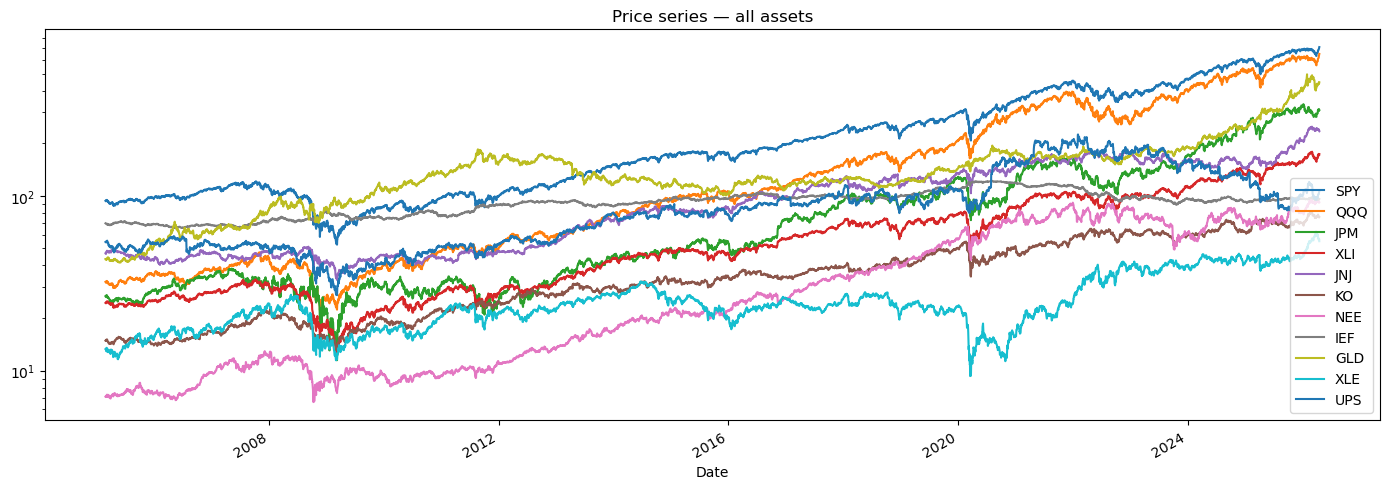

In [17]:
os.makedirs('outputs', exist_ok=True)

prices.plot(figsize=(14, 5), title='Price series — all assets', logy=True)
plt.tight_layout()
plt.savefig('outputs/price_check.png', dpi=150)